# Grad-CAM on Uncertain Predictions

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input


Mounted at /content/drive


## Load Trained Model (with Dropout)

In [3]:
from tensorflow.keras import backend as K

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=1)
    return loss

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/pneumonia_project/vgg19_final_model_colab.h5",
    custom_objects={'loss': focal_loss()}
)


## MC Dropout + Grad-CAM Utilities

In [4]:
def predict_with_uncertainty(model, img_array, n_iter=30):
    predictions = np.array([model(img_array, training=True).numpy()[0] for _ in range(n_iter)])
    mean_pred = np.mean(predictions, axis=0)
    std_pred = np.std(predictions, axis=0)
    return mean_pred, std_pred

def make_gradcam_heatmap(img_array, model, last_conv_layer='block5_conv4'):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        class_output = predictions[:, class_idx]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()


## Grad-CAM Overlay

In [5]:
def show_gradcam(img_path, model, class_names):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    mean_pred, std_pred = predict_with_uncertainty(model, img_array)
    pred_class = np.argmax(mean_pred)
    max_std = np.max(std_pred)

    print("\n🔍 Prediction Probabilities:")
    for i, cls in enumerate(class_names):
        print(f"{cls}: {mean_pred[i]*100:.2f}% ± {std_pred[i]*100:.2f}%")

    print(f"\nPredicted: {class_names[pred_class]} | Max Uncertainty: {max_std:.2f}")

    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, model)

    # Overlay Grad-CAM
    img_raw = cv2.imread(img_path)
    img_raw = cv2.resize(img_raw, (224, 224))
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlayed = cv2.addWeighted(img_raw, 0.6, heatmap_colored, 0.4, 0)

    # Show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM")
    plt.imshow(cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.tight_layout()
    plt.show()


## Run It on Sample Image


🔍 Prediction Probabilities:
COVID-19: 0.00% ± 0.00%
Normal: 3.36% ± 17.74%
Pneumonia-Bacterial: 96.64% ± 17.74%
Pneumonia-Viral: 0.00% ± 0.00%

Predicted: Pneumonia-Bacterial | Max Uncertainty: 0.18


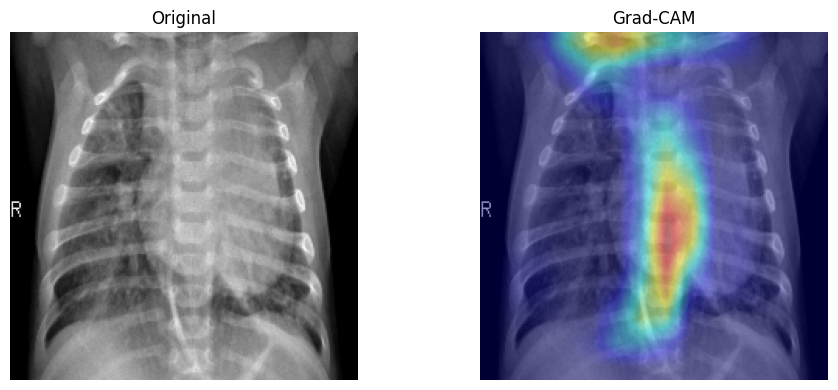

In [10]:
class_names = ["COVID-19", "Normal", "Pneumonia-Bacterial", "Pneumonia-Viral"]

img_path = "/content/drive/MyDrive/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"
show_gradcam(img_path, model, class_names)
